<a href="https://colab.research.google.com/github/kaleigh-west/DS4002_Project3/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [13]:
# Upload to Colab (skip if not using Colab)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
base_dir = "/content/drive/MyDrive/Colab_Notebooks/Brain_Tumor_data"
new_size = (224, 224)

for split in ["Training", "Testing"]:
    split_path = os.path.join(base_dir, split)

    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)

        if os.path.isdir(label_path):
            for filename in os.listdir(label_path):
                file_path = os.path.join(label_path, filename)

                try:
                    with Image.open(file_path) as img:
                        img = img.convert("RGB")
                        img = img.resize(new_size)
                        img.save(file_path)
                except Exception as e:
                    print(f"Skipped {file_path}: {e}")

print("All images resized.")

All images resized.


In [23]:
# Store counts of each tumor type in data frame
counts = {}

for split in ["Training", "Testing"]:
    split_path = os.path.join(base_dir, split)
    counts[split] = {}

    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)

        if os.path.isdir(label_path):
            num_images = len([
                f for f in os.listdir(label_path)
                if f.endswith(".jpg")
            ])

            counts[split][label] = num_images


tumors_summary = pd.DataFrame(counts).T
tumors_summary.loc["Total"] = tumors_summary.sum()

tumors_summary

,notumor,glioma,pituitary,meningioma
Training,1595,1321,1457,1339
Testing,405,300,300,306
Total,2000,1621,1757,1645


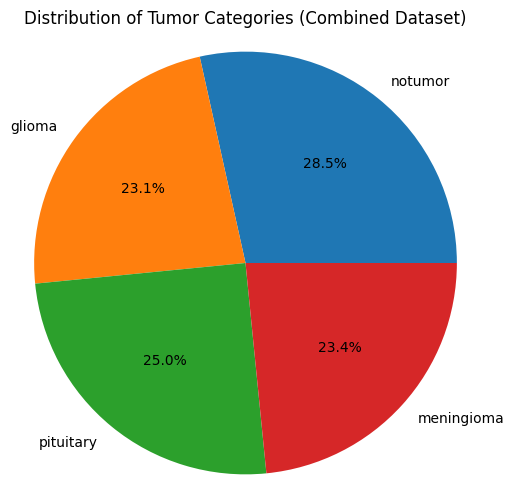

In [28]:
# Plot overall categorical distributions
plt.figure(figsize=(6, 6))
plt.pie(tumors_summary.loc["Total"].values, labels=tumors_summary.loc["Total"].index, autopct='%1.1f%%')
plt.title('Distribution of Tumor Categories (Combined Dataset)')
plt.axis('equal')  # Make the pie chart circular
plt.show()

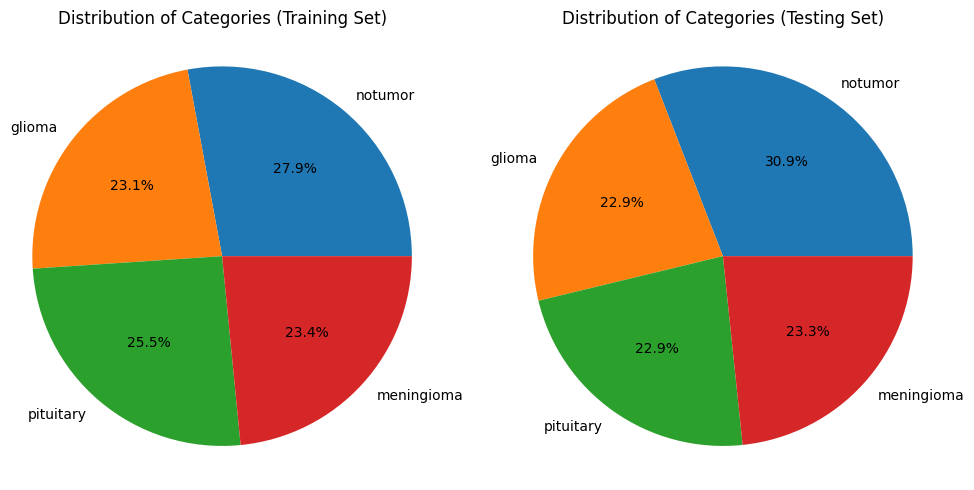

In [26]:
# Plot distributions by set

# Create a figure and a set of subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Plot the first pie chart on ax1
ax1.pie(tumors_summary.loc["Training"].values, labels=tumors_summary.loc["Training"].index, autopct='%1.1f%%')
ax1.set_title('Distribution of Categories (Training Set)')
ax1.axis('equal') # Ensure the pie charts are equal sizes

# Plot the second pie chart on ax2
ax2.pie(tumors_summary.loc["Testing"].values, labels=tumors_summary.loc["Testing"].index, autopct='%1.1f%%')
ax2.set_title('Distribution of Categories (Testing Set)')
ax2.axis('equal') # Ensure the pie charts are equal sizes

# Adjust layout and display the plots (prevent titles/labels from overlapping)
plt.tight_layout()
